# Torondel et al. (2016) — Pit Latrine Bacterial Ecology, Partially Reproduced with Pyloseq

**Reference:** Torondel B, Ensink JHJ, Gundogdu O, Ijaz UZ, Parkhill J, Abdelahi F, Nguyen V-A, Sudgen S, Gibson W, Walker AW, Quince C (2016). *Assessment of the influence of intrinsic environmental and geographical factors on the bacterial ecology of pit latrines.* **Microbial Biotechnology** 9(2): 209–223. DOI: [10.1111/1751-7915.12334](https://doi.org/10.1111/1751-7915.12334).

Bacterial communities from 30 pit latrines in Tanzania and Vietnam were profiled by 16S rRNA pyrosequencing and related to environmental variables (pH, temperature, organic-matter content/composition) and geography. The dataset is the basis of Umer Ijaz's widely-used phyloseq tutorial ([userweb.eng.gla.ac.uk/umer.ijaz/bioinformatics/ecological.html](http://userweb.eng.gla.ac.uk/umer.ijaz/bioinformatics/ecological.html)) and of the **microbiomeSeq** package.

This notebook reproduces the `phyloseq.R` workflow from that tutorial using the Python `pyloseq` package, following the same structure as our [McMurdie & Holmes (2013)](06_mcmurdie_holmes_2013.ipynb) reproduction. Each code cell shows the original R call it mirrors. Where pyloseq diverges from R phyloseq, the difference is called out inline and summarized at the end.

---
### Setup

In [ ]:
import warnings

import pandas as pd
from skbio.stats.distance import permanova

from pyloseq import (
    OtuTable,
    Phyloseq,
    PhyTree,
    SampleData,
    TaxTable,
    gunifrac,
    make_network,
    ordinate,
    plot_bar,
    plot_heatmap,
    plot_network,
    plot_ordination,
    plot_richness,
    plot_tree,
    prune_taxa,
    subset_samples,
    subset_taxa,
)

warnings.filterwarnings("ignore")

DATA = "data/torondel"

---
### 1. Load and Build the Phyloseq Object

Four files from the tutorial:

| File | Contents |
|------|----------|
| `All_Good_P2_C03.csv` | OTU abundance table (OTUs × samples) |
| `ENV_pitlatrine.csv` | Environmental / sample metadata |
| `All_Good_P2_C03_Taxonomy.csv` | RDP taxonomy per OTU (Domain → Genus) |
| `All_Good_P2_C03.tre` | FastTree phylogeny (Newick) |

The sample names encode three grouping factors — e.g. `T_2_1` is **Country** `T` (Tanzania; `V` = Vietnam), **Latrine** `2`, **Depth** `1`. We split these out into metadata columns exactly as the R code does with `strsplit(..., "_")`.

In [23]:
# R: abund_table <- read.csv("All_Good_P2_C03.csv", row.names=1, check.names=FALSE)
abund_table = pd.read_csv(f"{DATA}/All_Good_P2_C03.csv", index_col=0)  # OTUs x samples

# R: meta_table <- read.csv("ENV_pitlatrine.csv", row.names=1, check.names=FALSE)
meta_table = pd.read_csv(f"{DATA}/ENV_pitlatrine.csv", index_col=0)

# R: grouping_info <- ... strsplit(rownames(meta_table), "_") ; colnames <- Country/Latrine/Depth
grouping = meta_table.index.to_series().str.split("_", expand=True)
meta_table["Country"] = grouping[0]
meta_table["Latrine"] = grouping[1]
meta_table["Depth"] = grouping[2]

# R: abund_table <- abund_table[rownames(abund_table) %in% rownames(meta_table), ]
#    (R transposes first so samples are rows; here samples are columns, so we filter columns)
common = [s for s in abund_table.columns if s in meta_table.index]
abund_table = abund_table[common]
meta_table = meta_table.loc[common]

# R: OTU_taxonomy <- read.csv("All_Good_P2_C03_Taxonomy.csv", row.names=1, check.names=FALSE)
otu_taxonomy = pd.read_csv(f"{DATA}/All_Good_P2_C03_Taxonomy.csv", index_col=0).reindex(abund_table.index)

print(f"OTU table: {abund_table.shape[0]} OTUs x {abund_table.shape[1]} samples")
print(f"Metadata:  {meta_table.shape[1]} variables -> {list(meta_table.columns)}")
meta_table.head()

OTU table: 12715 OTUs x 81 samples
Metadata:  14 variables -> ['pH', 'Temp', 'TS', 'VS', 'VFA', 'CODt', 'CODs', 'perCODsbyt', 'NH4', 'Prot', 'Carbo', 'Country', 'Latrine', 'Depth']


,pH,Temp,TS,VS,VFA,CODt,CODs,perCODsbyt,NH4,Prot,Carbo,Country,Latrine,Depth
Samples,,,,,,,,,,,,,,
T_2_1,7.82,25.1,14.53,71.33,71.0,874,311,36,3.3,35.4,22.0,T,2,1
T_2_2,6.49,29.6,13.91,64.93,3.7,389,180,46,6.2,29.3,25.0,T,2,2
T_2_3,6.46,27.9,29.45,26.85,27.5,161,35,22,2.4,19.4,31.0,T,2,3
T_2_6,7.69,28.7,65.52,7.03,1.5,57,3,6,0.8,0.0,14.0,T,2,6
T_2_7,7.48,29.8,36.03,34.11,1.1,107,9,8,0.7,14.1,28.0,T,2,7


#### Rooting the tree

The FastTree output is **unrooted**. R phyloseq silently roots an unrooted tree on the fly (picking a random tip) inside `ordinate(..., "unifrac")`; **pyloseq requires an explicitly rooted tree** and raises `ValueError: The tree must be rooted` otherwise. The tutorial itself recommends principled **midpoint rooting** (via `phangorn::midpoint` for the GUniFrac section), so we root once up front and use it everywhere. This is the first behavioral difference vs. R phyloseq (see the closing notes).

In [24]:
# R (GUniFrac section): midpoint(phy_tree(physeq_subset))  -- phangorn midpoint rooting
unrooted = PhyTree.from_newick(open(f"{DATA}/All_Good_P2_C03.tre").read())
phy_tree = PhyTree.from_newick(str(unrooted._tree.root_at_midpoint()))
print(f"Unrooted tips: {unrooted.n_tips} | rooted: {phy_tree.is_rooted}")

Unrooted tips: 11853 | rooted: True


In [25]:
# R: OTU = otu_table(as.matrix(abund_table), taxa_are_rows=FALSE)
#    TAX = tax_table(as.matrix(OTU_taxonomy))
#    SAM = sample_data(meta_table)
#    physeq <- merge_phyloseq(phyloseq(OTU, TAX), SAM, OTU_tree)
physeq = Phyloseq(
    otu=OtuTable(abund_table, taxa_are_rows=True),
    sam=SampleData(meta_table),
    tax=TaxTable(otu_taxonomy),
    tree=phy_tree,
)

print(f"Taxa:    {physeq.ntaxa}")
print(f"Samples: {physeq.nsamples}")
print(f"Ranks:   {physeq.rank_names}")
print(f"Countries: {sorted(meta_table['Country'].unique())}  (T=Tanzania, V=Vietnam)")

Taxa:    12715
Samples: 81
Ranks:   ['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus']
Countries: ['T', 'V']  (T=Tanzania, V=Vietnam)


---
### 2. Alpha Diversity — `plot_richness`

Per-sample richness estimators, samples grouped by **Country** on the x-axis and colored by **Depth**.

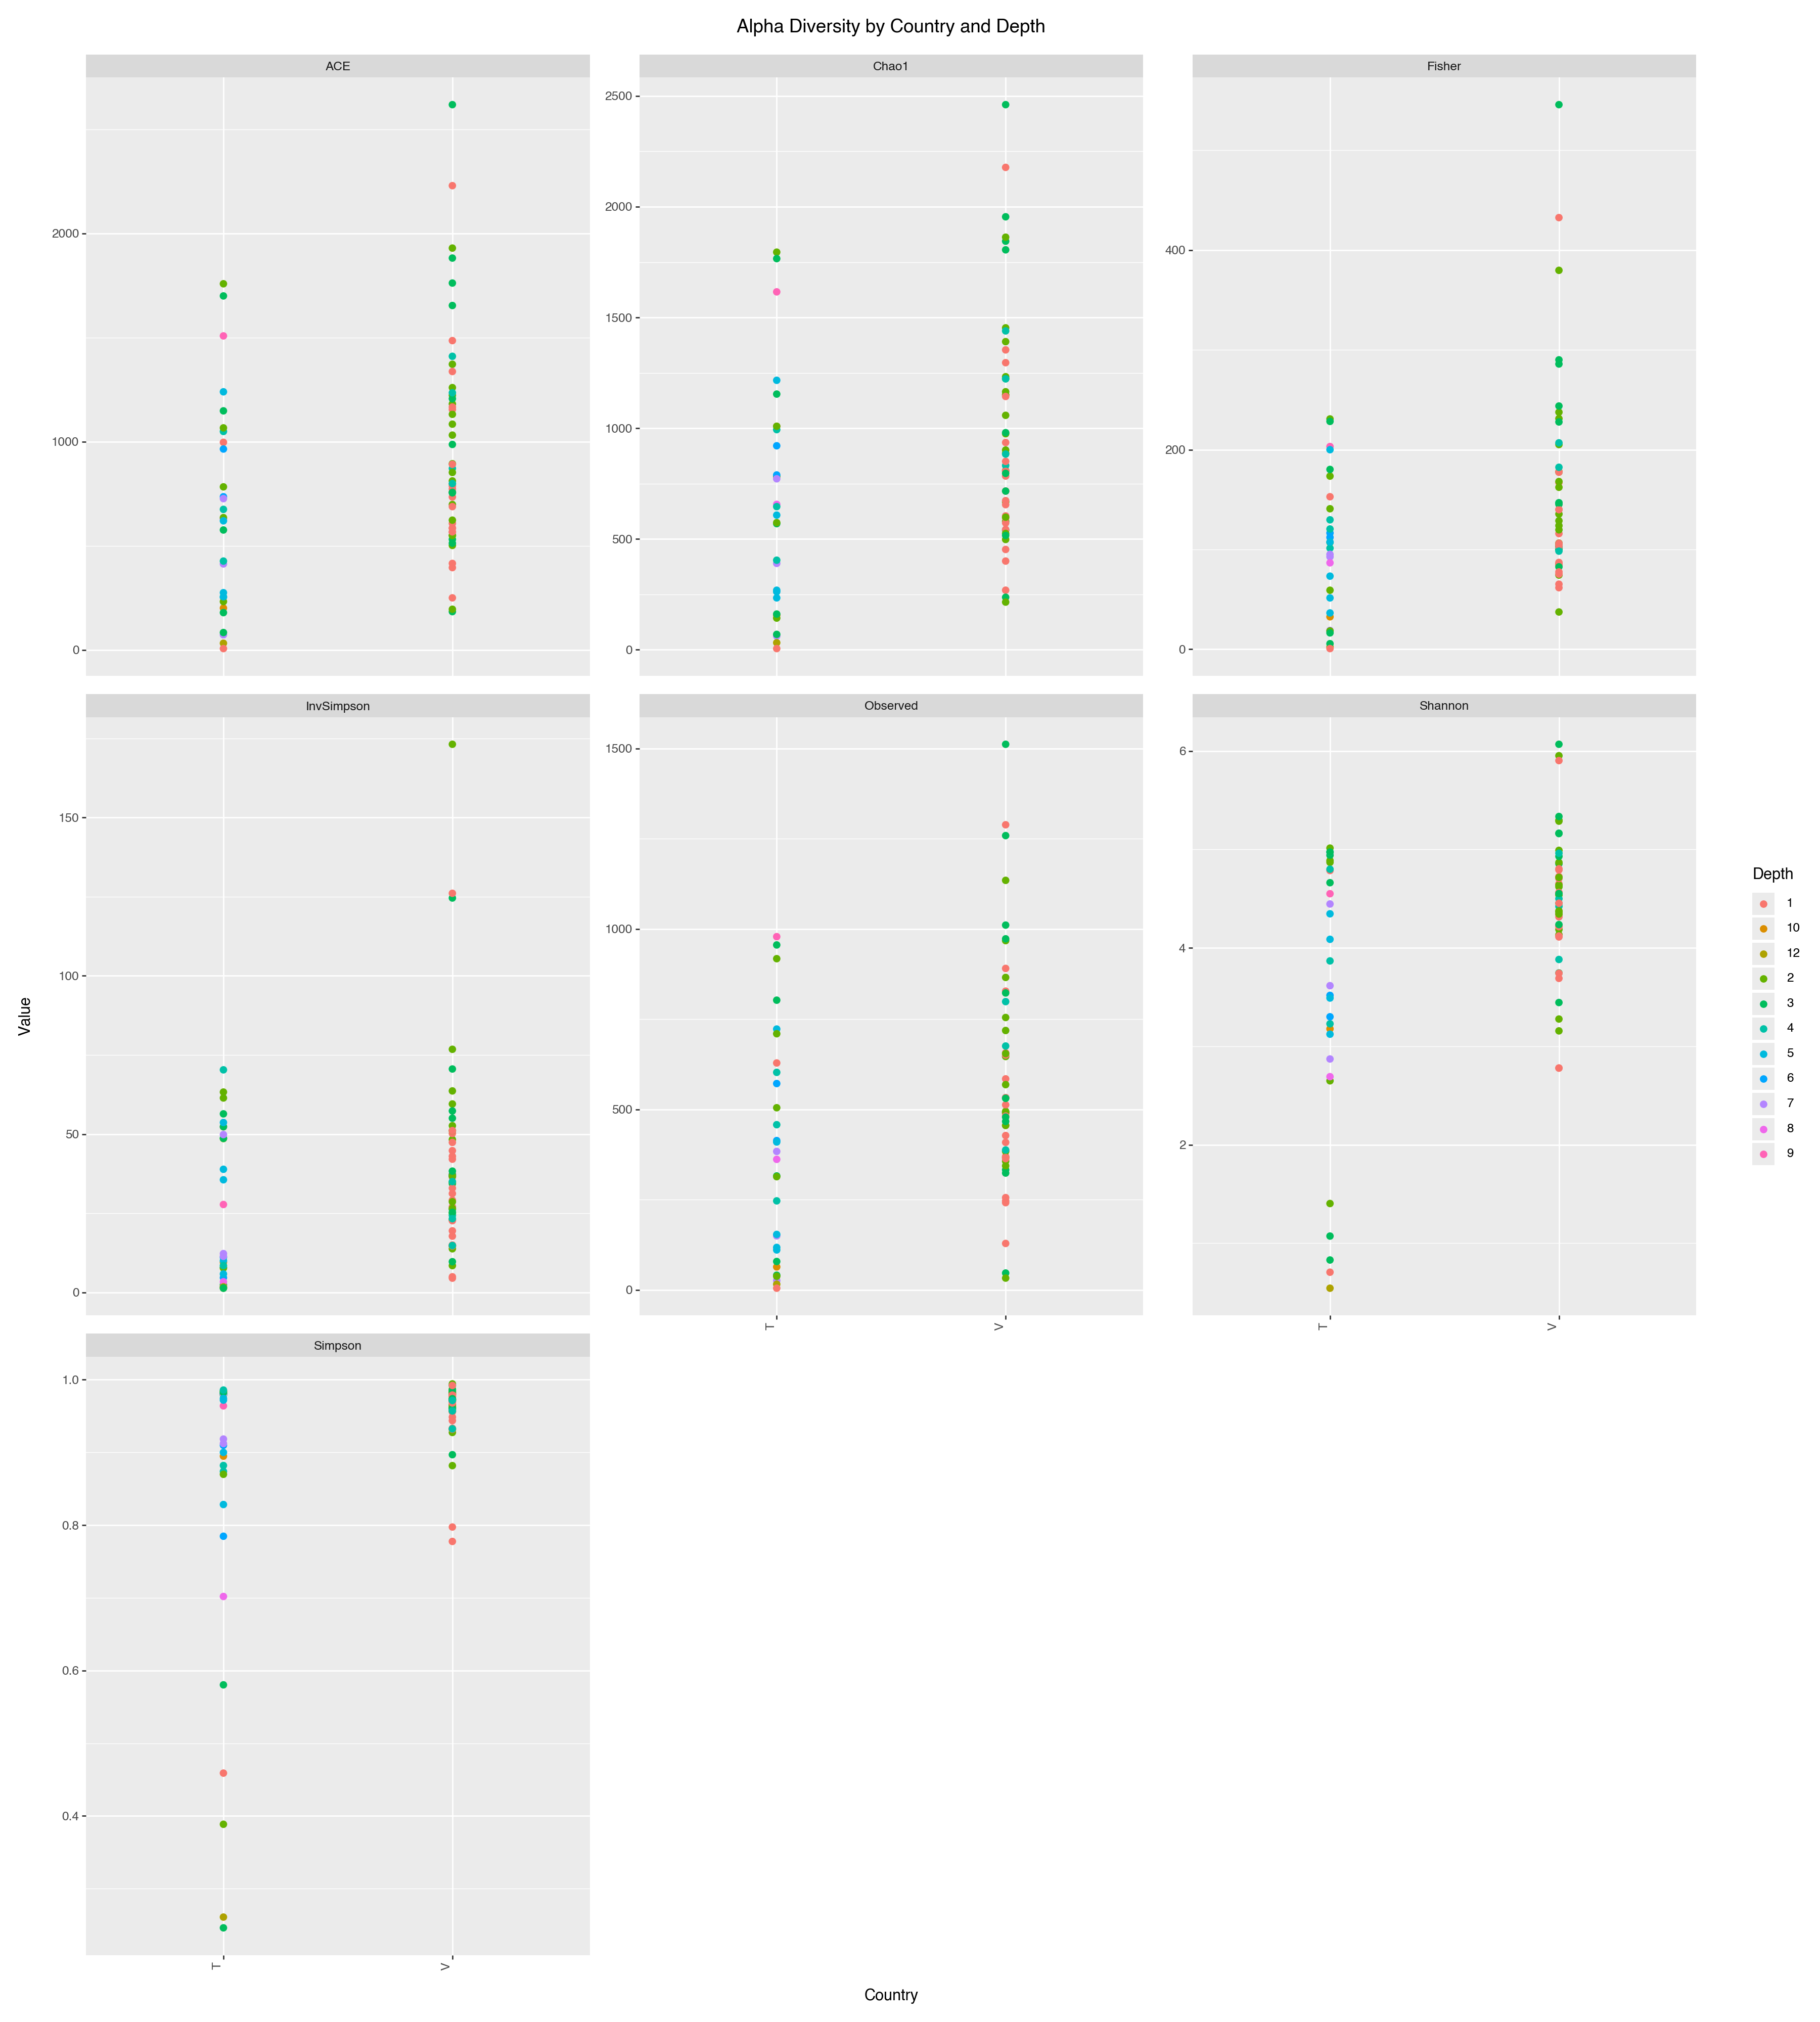

In [26]:
from plotnine import theme

# R: p <- plot_richness(physeq, x="Country", color="Depth") + theme_bw()
p = plot_richness(
    physeq,
    x="Country",
    color="Depth",
    title="Alpha Diversity by Country and Depth",
    boxplot=False,
)
p + theme(figure_size=(18, 20))

---
### 3. Phylogenetic Tree of Prevotellaceae at Depth 1 — `plot_tree`

Subset to the shallowest latrine layer (`Depth == "1"`) and to the family *Prevotellaceae*, then draw the tree with tips colored by country, labelled by genus, and sized by abundance.

Prevotellaceae @ Depth 1: 105 OTUs x 22 samples


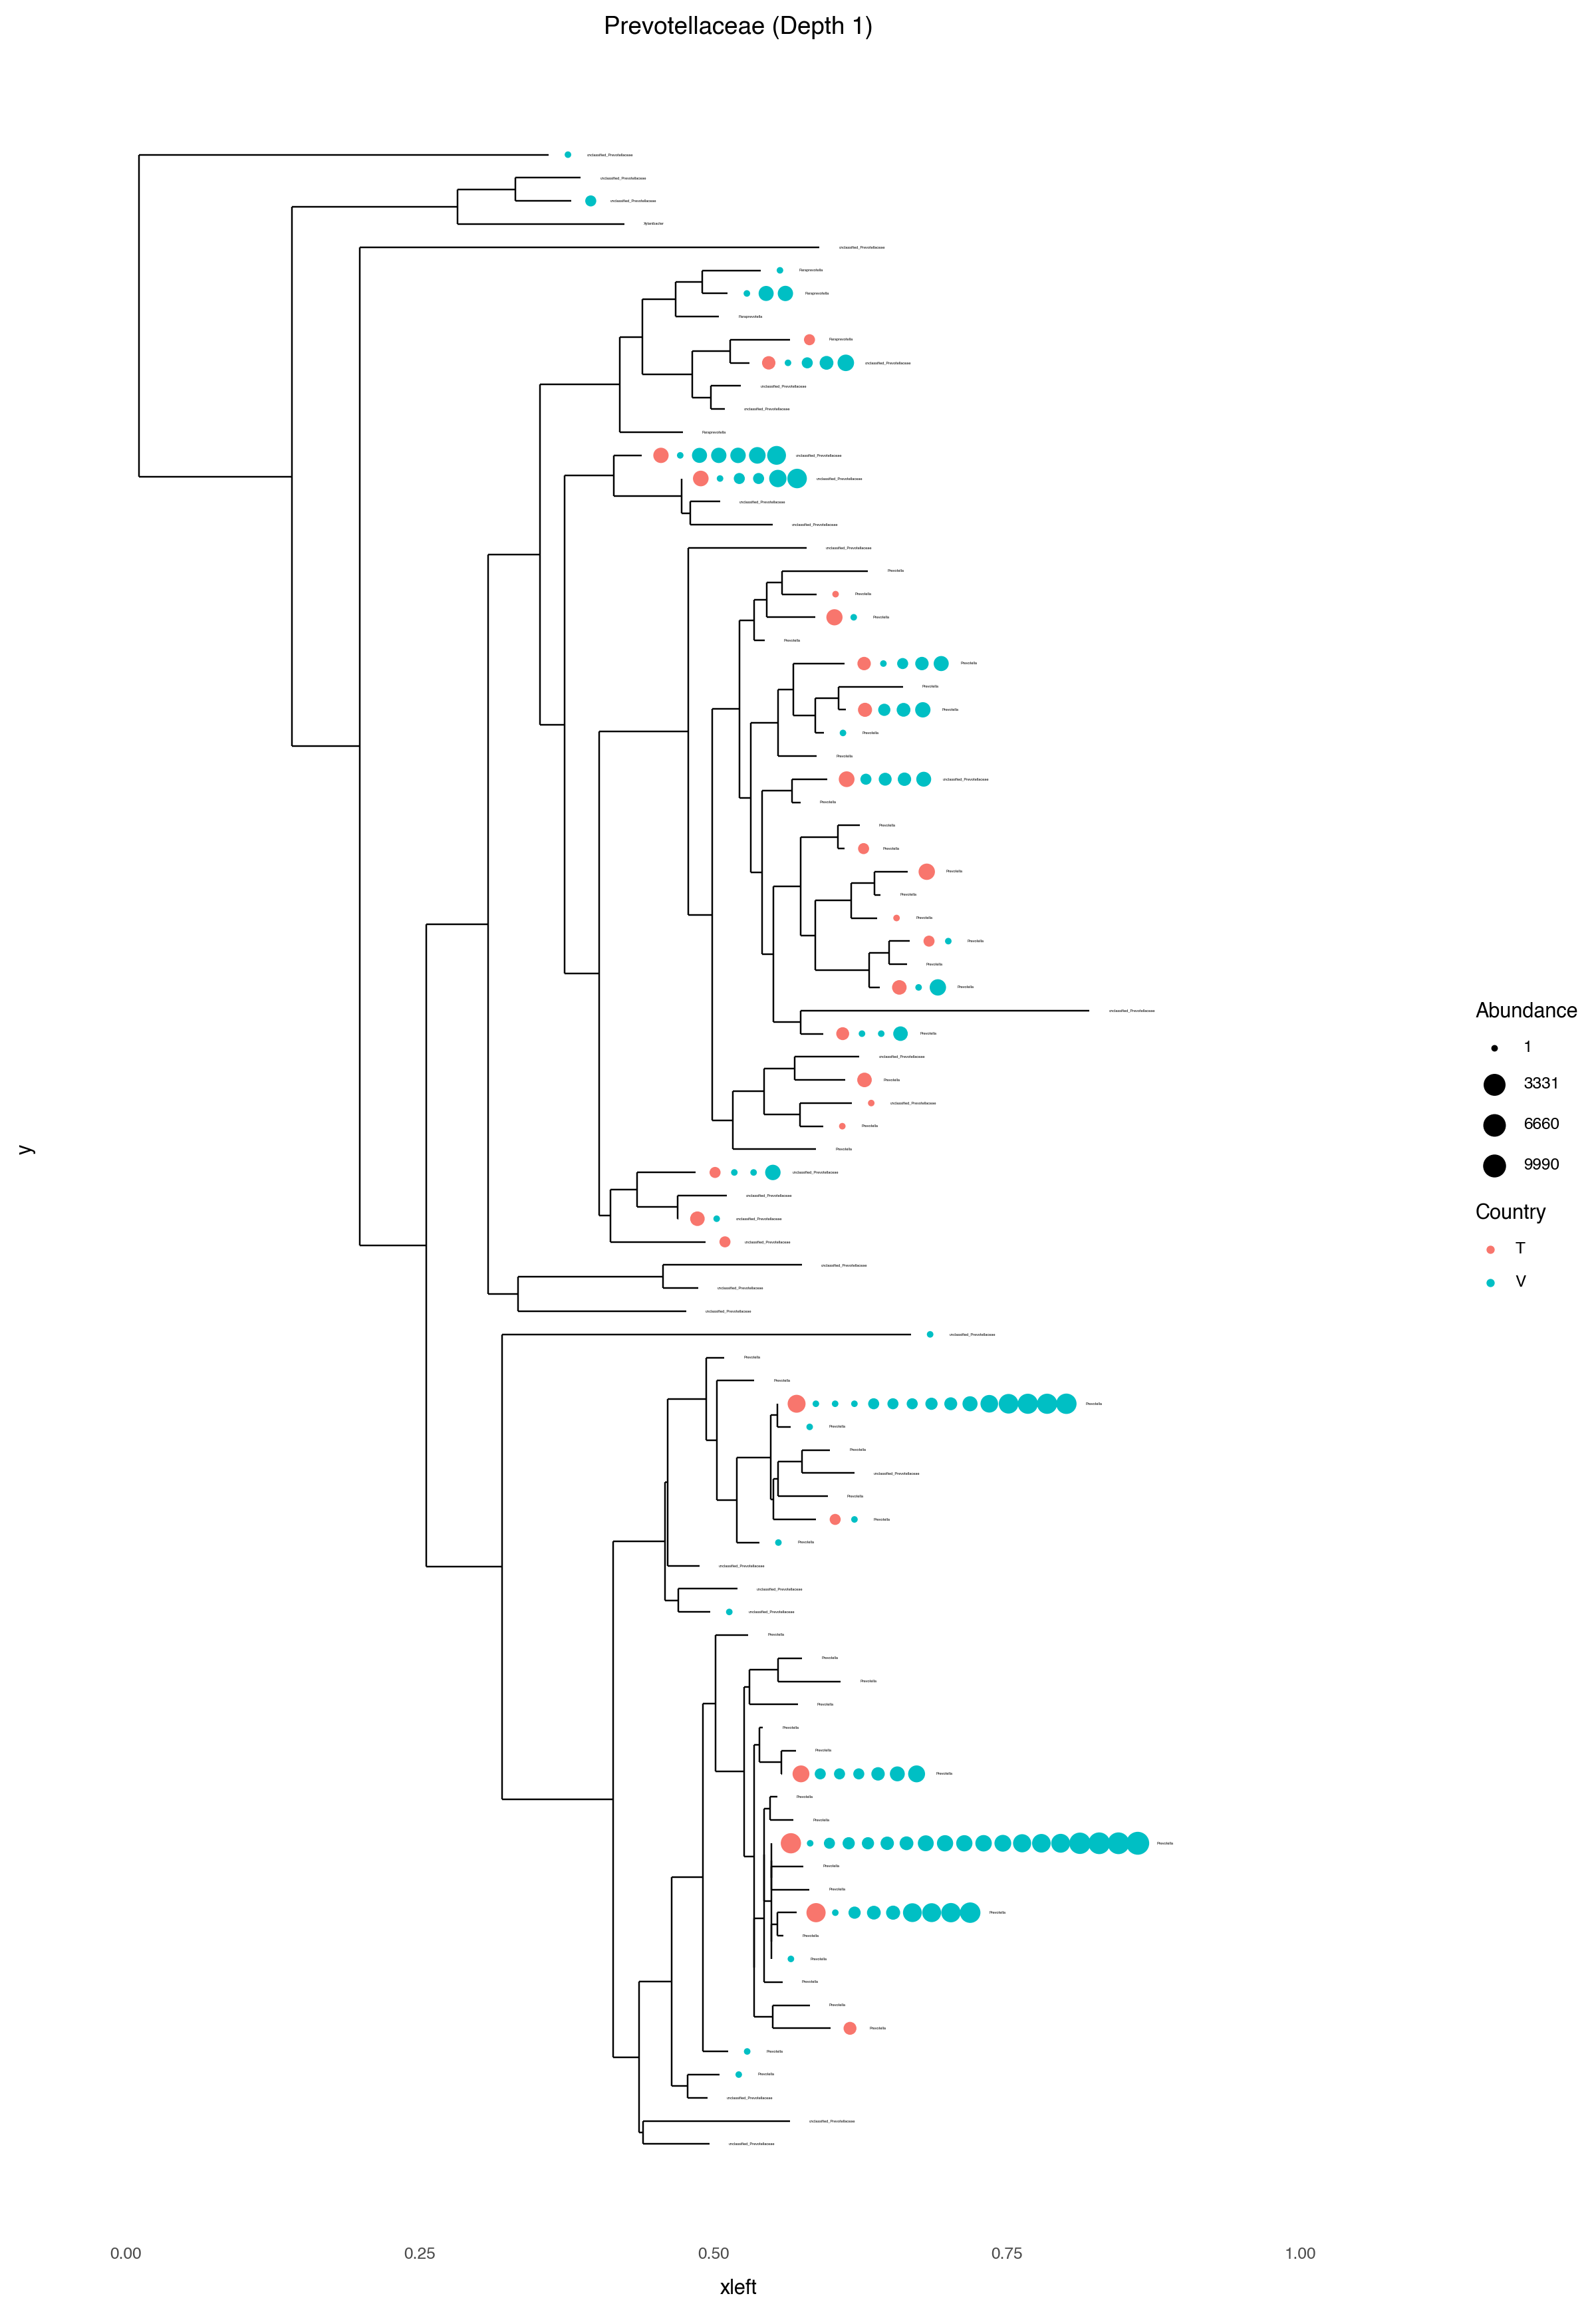

In [27]:
# R: physeq_subset <- subset_taxa(subset_samples(physeq, Depth=="1"), Family=="Prevotellaceae")
prevotella = subset_taxa(
    subset_samples(physeq, 'Depth == "1"'),
    'Family == "Prevotellaceae"',
)
print(f"Prevotellaceae @ Depth 1: {prevotella.ntaxa} OTUs x {prevotella.nsamples} samples")

# R: plot_tree(physeq_subset, color="Country", label.tips="Genus", size="abundance", text.size=2)
p = plot_tree(
    prevotella,
    color="Country",
    label_tips="Genus",
    size="Abundance",
    text_size=2,
    title="Prevotellaceae (Depth 1)",
)
p

---
### 4. Restrict to the 500 Most Abundant OTUs

The composition, heatmap, ordination and network plots all operate on the 500 highest-abundance OTUs, as in the tutorial.

Two alignment steps match R's exact behavior:
- **Select from tree taxa only.** R's `GUniFrac` errors if the OTU table contains taxa absent from the tree. R's phyloseq auto-prunes to the tree intersection at construction, so R's top-500 ranking draws from the ~11,853 tree-covered OTUs, not all 12,715.
- **Midpoint-root after pruning.** R calls `midpoint(phy_tree(physeq_subset))` on the already-pruned 500-tip tree; rooting the full tree first then pruning places the root differently and shifts pairwise distances enough to change network edges near the 0.4 threshold.

In [28]:
# R: physeq_subset <- prune_taxa(names(sort(taxa_sums(physeq), TRUE)[1:500]), physeq)
# Select top 500 from tree taxa only (R's GUniFrac errors on non-tree OTUs; R's phyloseq
# auto-prunes to tree intersection so its ranking also draws from tree taxa only).
tree_tips = {n.name for n in unrooted._tree.tips()}
tree_taxa_sums = physeq.taxa_sums()
tree_taxa_sums = tree_taxa_sums[tree_taxa_sums.index.isin(tree_tips)]
top500 = tree_taxa_sums.sort_values(ascending=False).index[:500]

# Prune with the unrooted tree so we get a 500-tip unrooted subtree, then midpoint-root it.
# This matches R: midpoint(phy_tree(physeq_subset)) roots the pruned tree, not the full tree.
physeq_unrooted = Phyloseq(
    otu=physeq.otu_table,
    sam=physeq.sample_data,
    tax=physeq.tax_table,
    tree=unrooted,
)
physeq_pruned = prune_taxa(list(top500), physeq_unrooted)
pruned_rooted = PhyTree.from_newick(str(physeq_pruned.phy_tree._tree.root_at_midpoint()))
physeq_subset = Phyloseq(
    otu=physeq_pruned.otu_table,
    sam=physeq_pruned.sample_data,
    tax=physeq_pruned.tax_table,
    tree=pruned_rooted,
)
print(f"Subset: {physeq_subset.ntaxa} taxa x {physeq_subset.nsamples} samples  (tree tips: {physeq_subset.phy_tree.n_tips})")

Subset: 500 taxa x 81 samples  (tree tips: 500)


---
### 5. Abundance Heatmap — `plot_heatmap`

The R call uses `method=NULL` (no ordination reordering) with `sample.label="Country"` and `taxa.label="Class"`. pyloseq's `plot_heatmap` now supports all three: `method=None` preserves the original sample/taxa order, `label` relabels the sample (x) axis from a `sample_data` column, and `taxa_label` relabels the OTU (y) axis from a `tax_table` rank — so the R call reproduces directly.

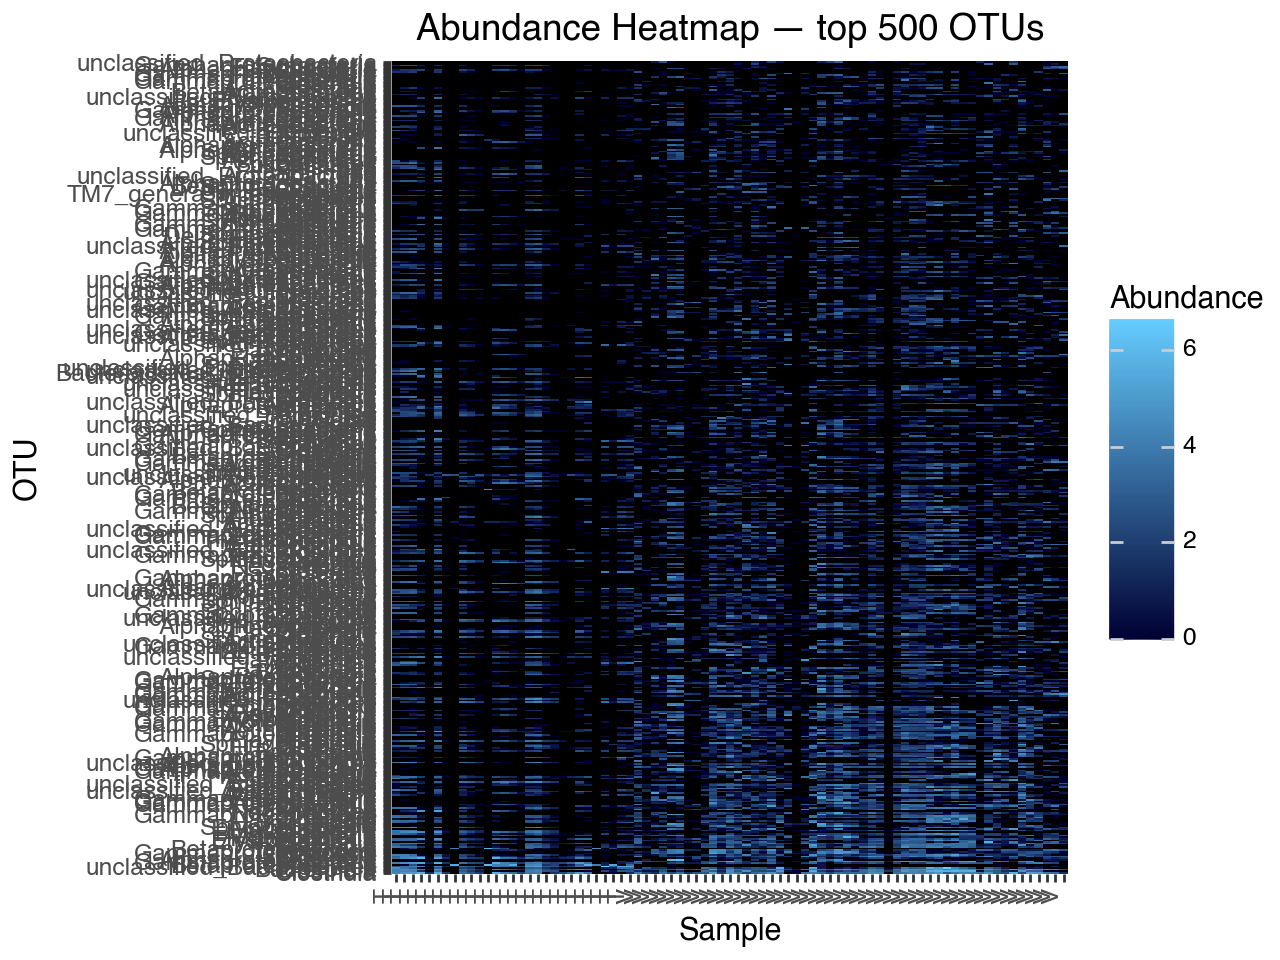

In [29]:
# R: plot_heatmap(physeq_subset, method=NULL, sample.label="Country", taxa.label="Class")
p = plot_heatmap(
    physeq_subset,
    method=None,
    label="Country",
    taxa_label="Class",
    title="Abundance Heatmap — top 500 OTUs",
)
p

---
### 6. Taxonomic Composition — `plot_bar`

Stacked phylum abundance per country, and a faceted version with one panel per country.

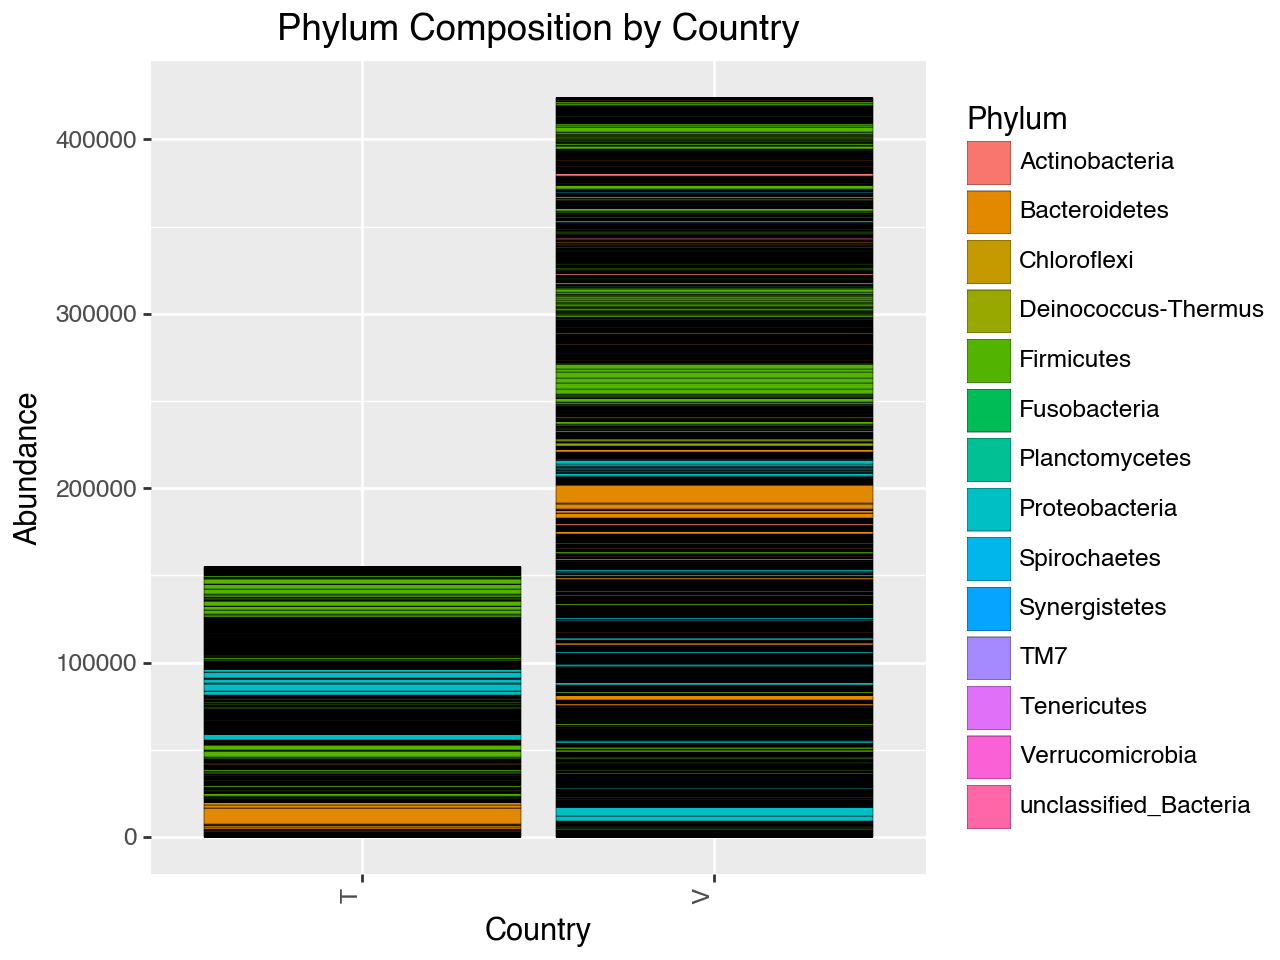

In [30]:
# R: plot_bar(physeq_subset, x="Country", fill="Phylum") + theme_bw()
p = plot_bar(
    physeq_subset,
    x="Country",
    fill="Phylum",
    title="Phylum Composition by Country",
)
p

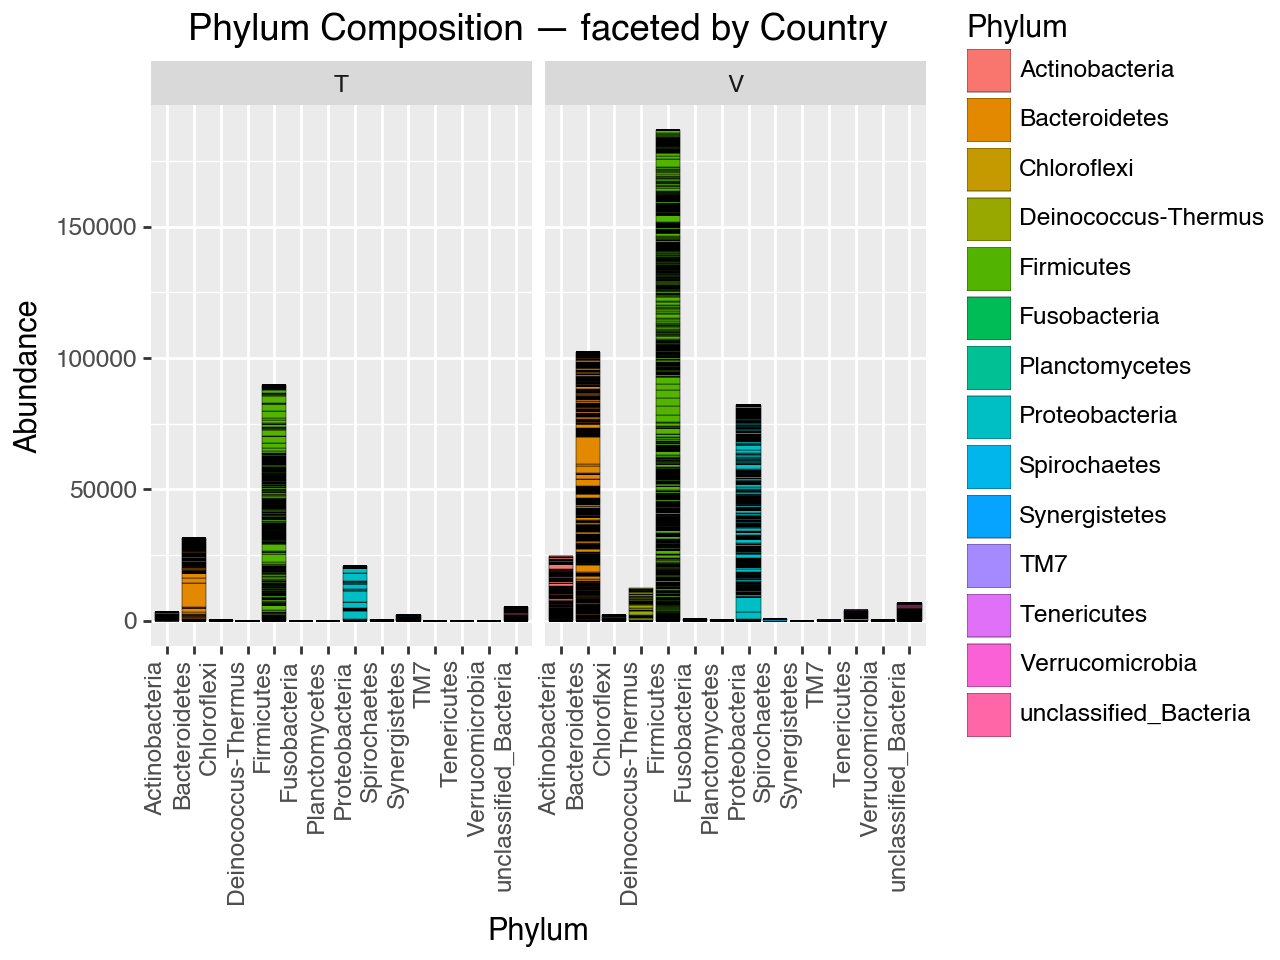

In [31]:
# R: plot_bar(physeq_subset, x="Phylum", fill="Phylum", facet_grid=~Country) + theme_bw()
p = plot_bar(
    physeq_subset,
    x="Phylum",
    fill="Phylum",
    facet_grid="~Country",
    title="Phylum Composition — faceted by Country",
)
p

---
### 7. Beta Diversity — GUniFrac PCoA

The R tutorial first calls `ordinate(physeq_subset, method="PCoA", distance="unifrac", weighted=TRUE)`, then uses the separate **GUniFrac** package to compute four more distance flavors via `GUniFrac(otu.tab, midpoint(phy_tree), alpha=c(0, 0.5, 1))$unifracs`, producing PCoA plots for each:

| Key | Distance |
|-----|----------|
| `d_1` | Weighted UniFrac (alpha = 1) |
| `d_UW` | Unweighted UniFrac |
| `d_VAW` | Variance-adjusted weighted UniFrac |
| `d_0` | GUniFrac alpha = 0 |
| `d_0.5` | GUniFrac alpha = 0.5 |

`pyloseq.gunifrac()` reproduces all five, implementing the Chen et al. (2012) formula directly using the midpoint-rooted tree from §1. `ordinate()` accepts a precomputed `DistanceMatrix`, so each PCoA is a one-liner.

In [32]:
# R: unifracs <- GUniFrac(as.matrix(otu_table(physeq_subset)),
#                         midpoint(phy_tree(physeq_subset)), alpha=c(0, 0.5, 1))$unifracs
unifracs = gunifrac(physeq_subset, alpha=(0, 0.5, 1))
dw = unifracs["d_1"]    # Weighted UniFrac
du = unifracs["d_UW"]   # Unweighted UniFrac
dv = unifracs["d_VAW"]  # Variance-adjusted weighted UniFrac
d0 = unifracs["d_0"]    # GUniFrac alpha = 0
d5 = unifracs["d_0.5"]  # GUniFrac alpha = 0.5
print("Computed:", list(unifracs.keys()))

Computed: ['d_0', 'd_0.5', 'd_1', 'd_UW', 'd_VAW']


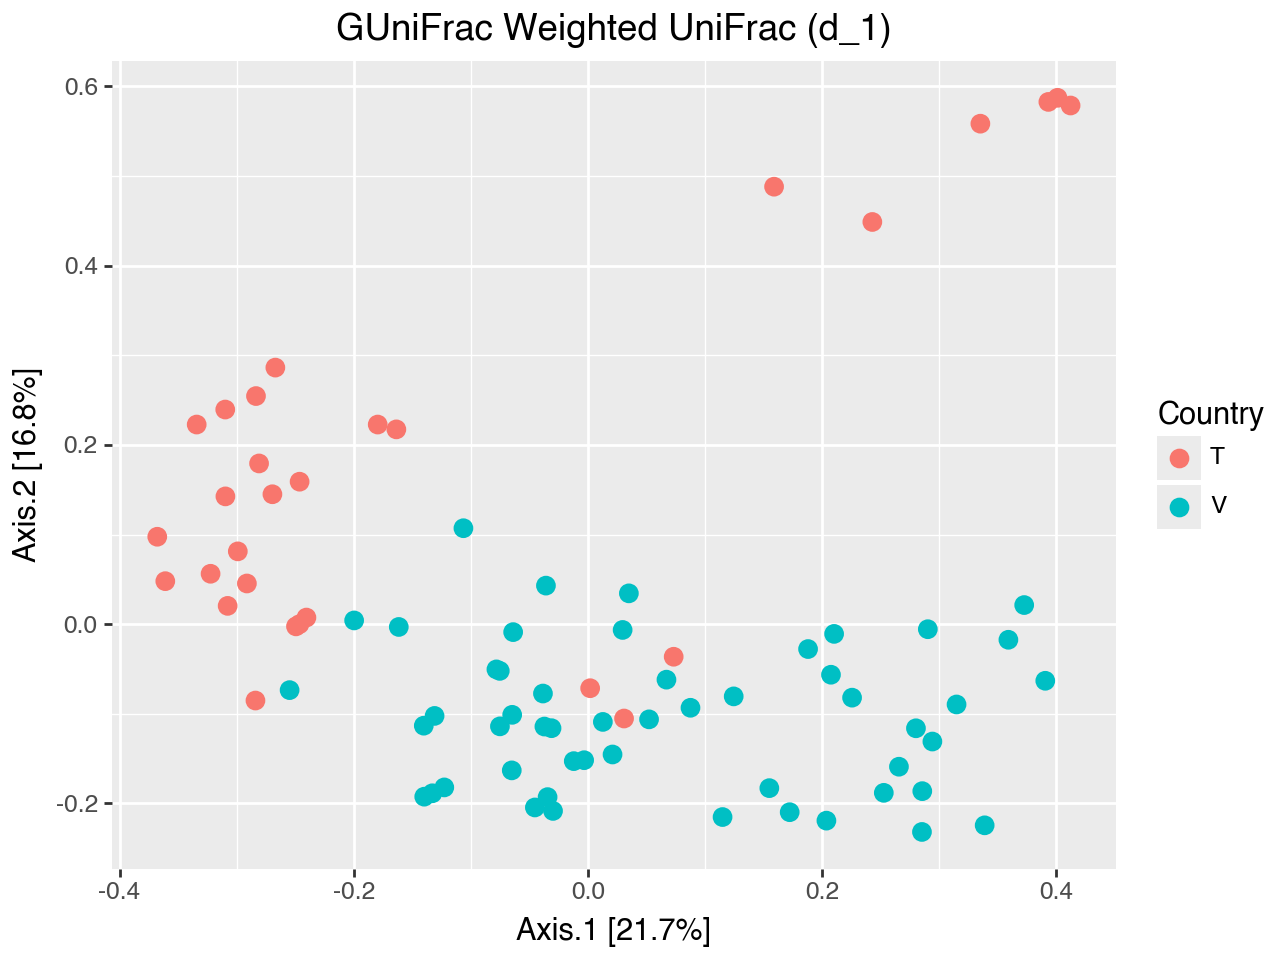

In [33]:
# R: ord <- ordinate(physeq_subset, method="PCoA", distance="unifrac", weighted=TRUE)
#    p <- plot_ordination(physeq_subset, ord, color="Country",
#                         title="Phyloseq's Weighted Unifrac") + geom_point(size=5)
pcoa_dw = ordinate(physeq_subset, method="PCoA", distance=dw)
p = plot_ordination(physeq_subset, pcoa_dw, color="Country", title="GUniFrac Weighted UniFrac (d_1)")
p

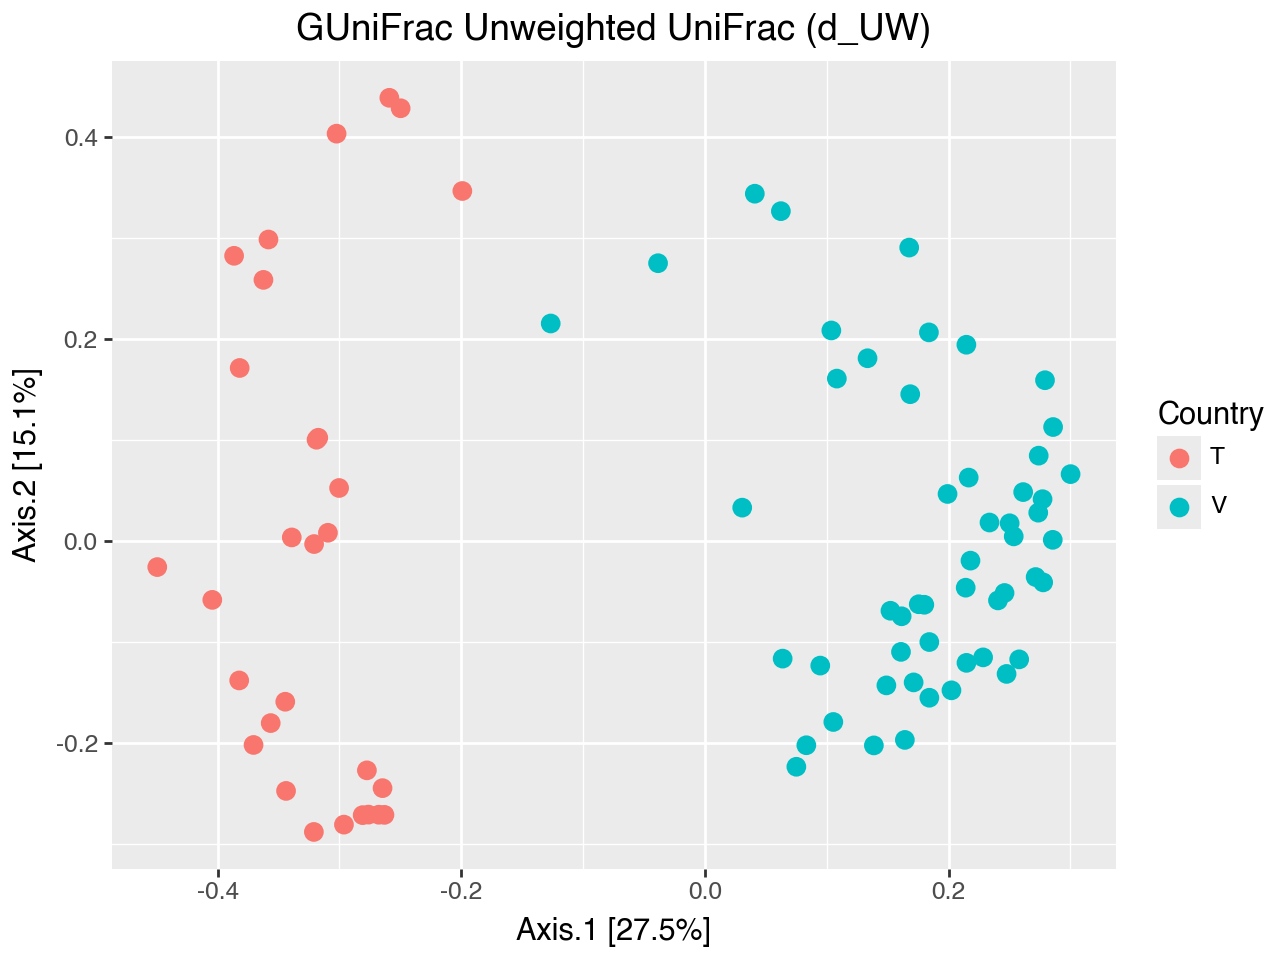

In [34]:
# R: pcoa <- cmdscale(du, ...) ; plot_ordination(..., title="GUniFrac Unweighted UniFrac")
pcoa_du = ordinate(physeq_subset, method="PCoA", distance=du)
p = plot_ordination(physeq_subset, pcoa_du, color="Country", title="GUniFrac Unweighted UniFrac (d_UW)")
p

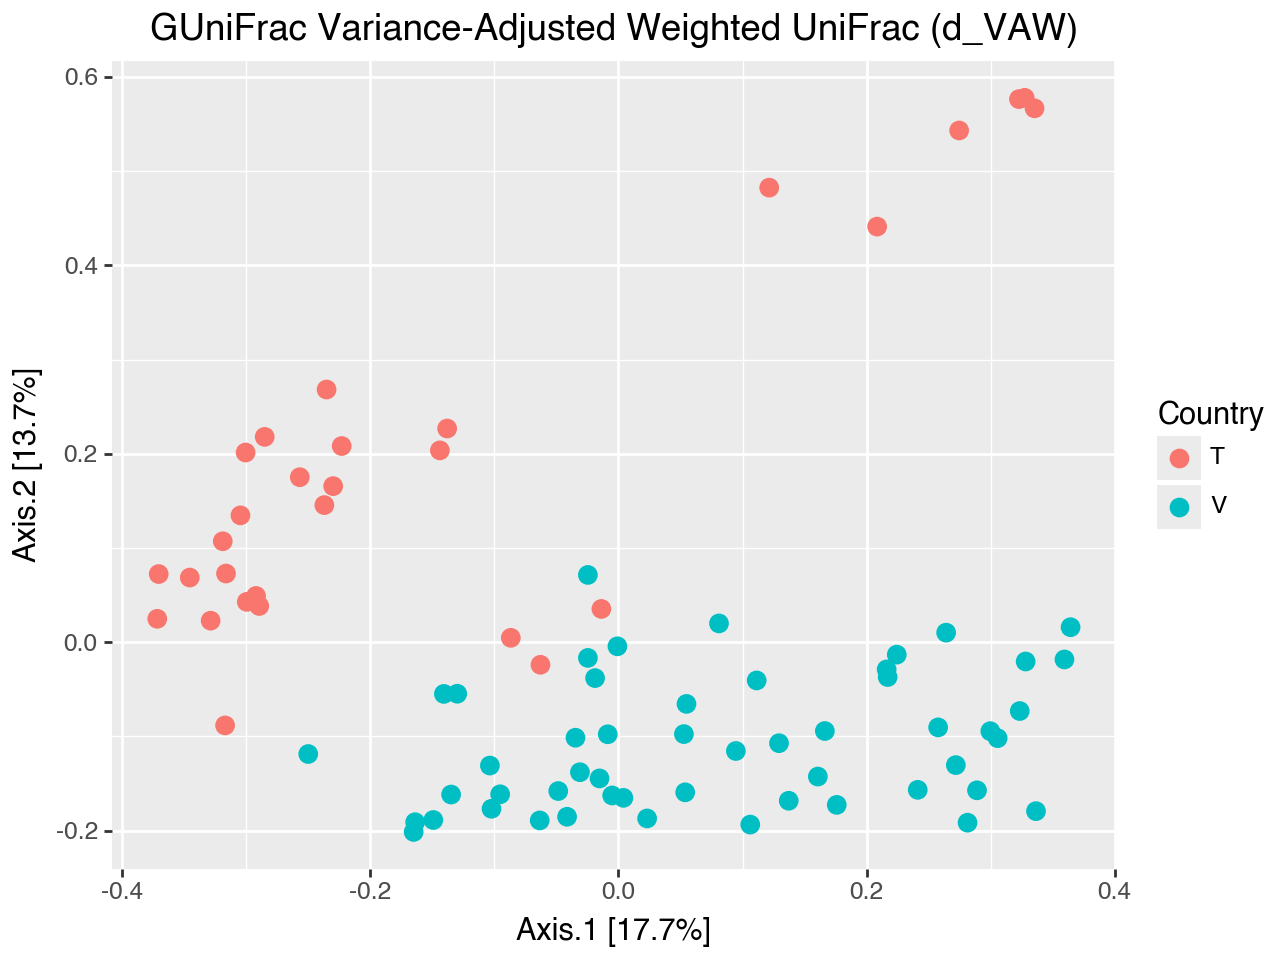

In [35]:
# R: pcoa <- cmdscale(dv, ...) ; plot_ordination(..., title="GUniFrac Variance adjusted weighted UniFrac")
pcoa_dv = ordinate(physeq_subset, method="PCoA", distance=dv)
p = plot_ordination(physeq_subset, pcoa_dv, color="Country", title="GUniFrac Variance-Adjusted Weighted UniFrac (d_VAW)")
p

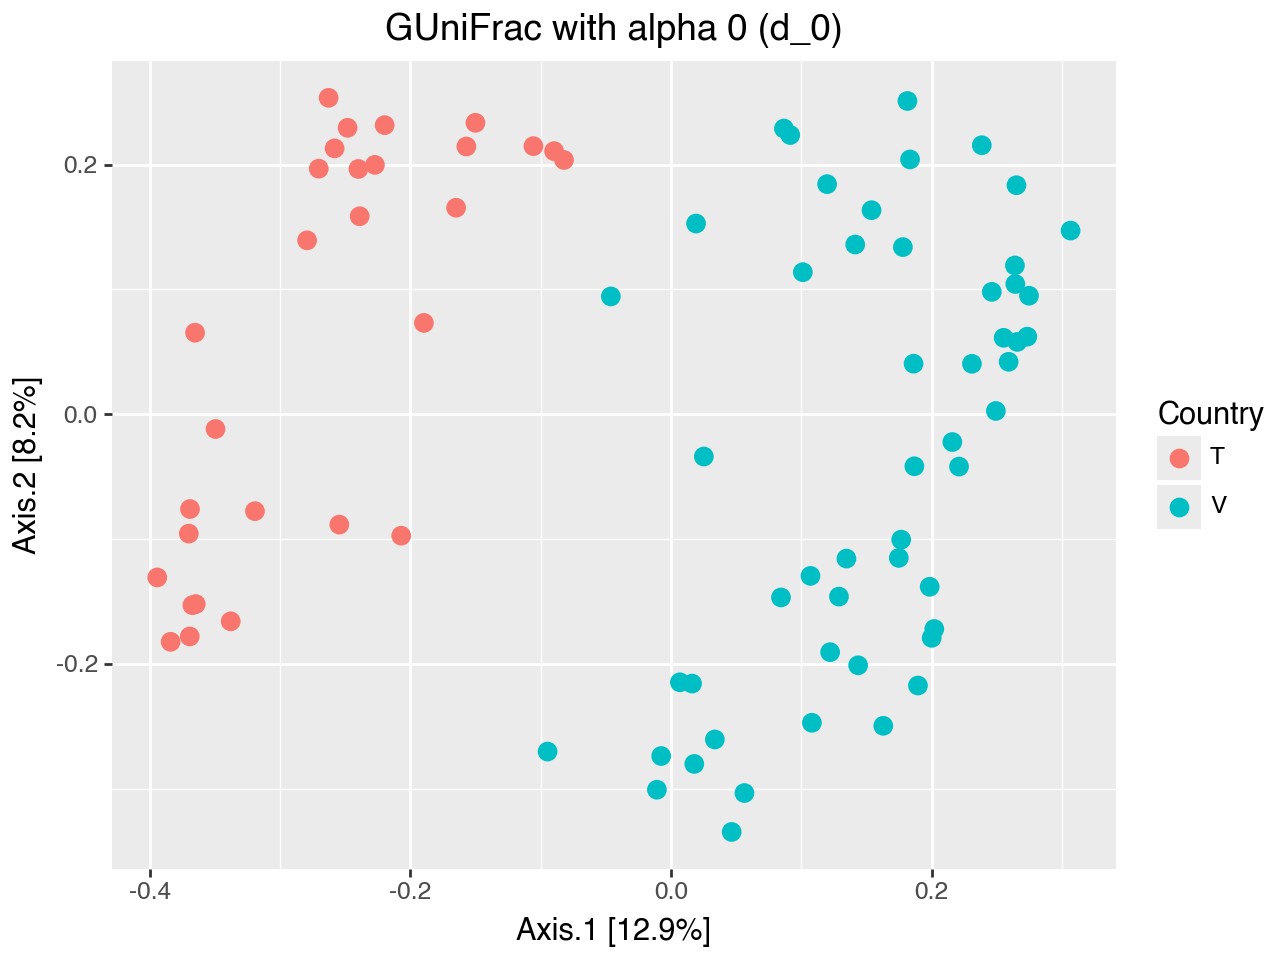

In [36]:
# R: pcoa <- cmdscale(d0, ...) ; plot_ordination(..., title="GUniFrac with alpha 0")
pcoa_d0 = ordinate(physeq_subset, method="PCoA", distance=d0)
p = plot_ordination(physeq_subset, pcoa_d0, color="Country", title="GUniFrac with alpha 0 (d_0)")
p

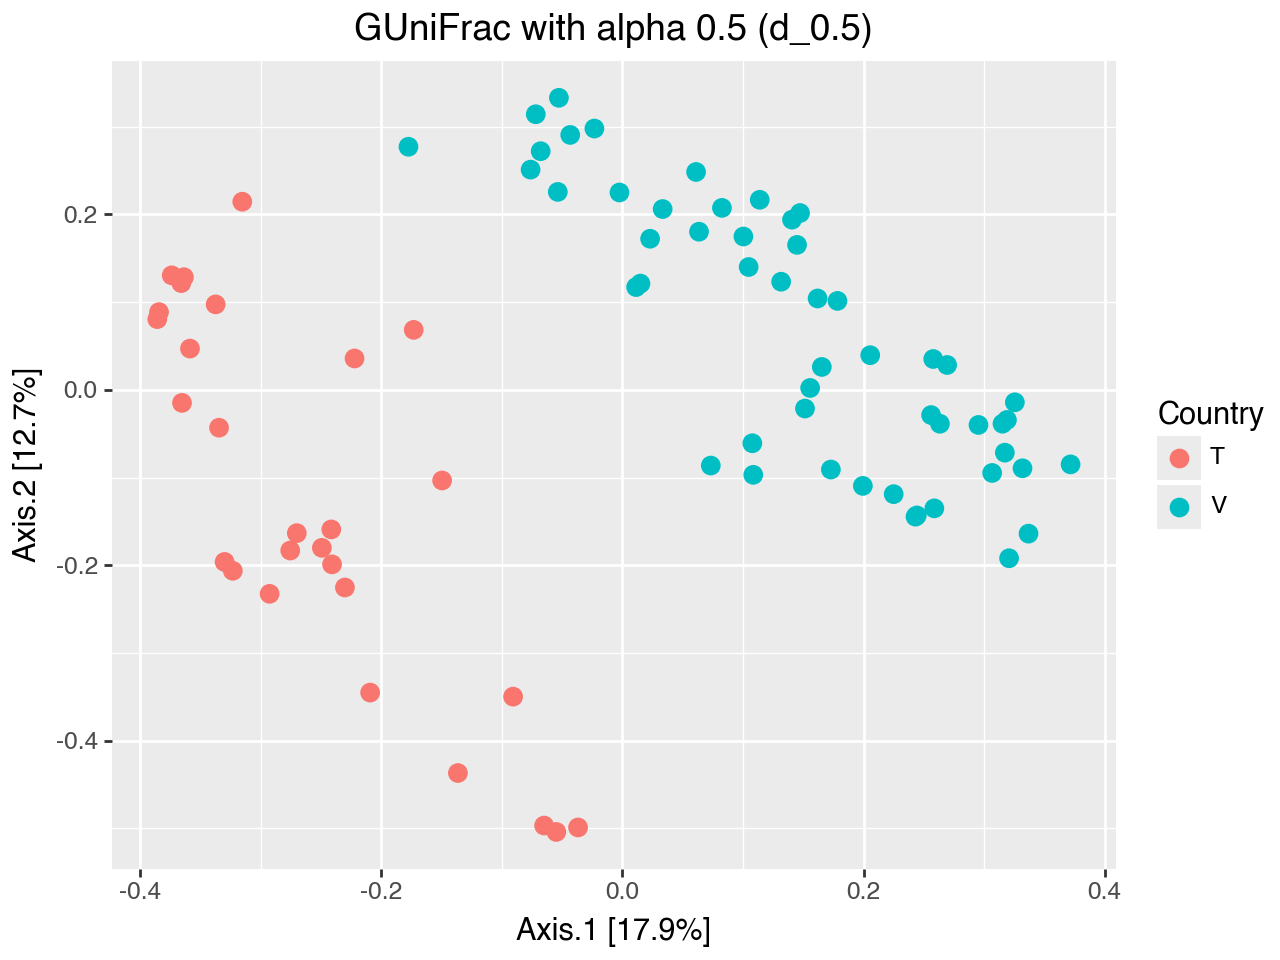

In [37]:
# R: pcoa <- cmdscale(d5, ...) ; plot_ordination(..., title="GUniFrac with alpha 0.5")
pcoa_d5 = ordinate(physeq_subset, method="PCoA", distance=d5)
p = plot_ordination(physeq_subset, pcoa_d5, color="Country", title="GUniFrac with alpha 0.5 (d_0.5)")
p

---
### 8. PERMANOVA — does community structure differ by country?

The tutorial runs `adonis(as.dist(d5) ~ Country)` — using **GUniFrac alpha = 0.5** (`d5`) — and reports pseudo-F ≈ 14.56, R² ≈ 0.156, p = 0.001. We replicate this exactly with scikit-bio's `permanova` on the same `d5` distance matrix.

In [38]:
# R: adonis(as.dist(d5) ~ as.matrix(sample_data(physeq_subset)[,"Country"]))
groups = physeq_subset.sample_data.to_frame().loc[list(d5.ids), "Country"]
result = permanova(d5, groups)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      81
number of groups                  2
test statistic            14.558062
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


In [39]:
# R: PermanovaG(unifracs[,, c("d_0","d_0.5","d_1")] ~ Country)
# PermanovaG tests with the maximum pseudo-F across multiple distance matrices.
# No direct Python equivalent; we run permanova on each distance and report all three.
print("GUniFrac PermanovaG approximation (pseudo-F and p per distance):")
for key, dm in [("d_0", d0), ("d_0.5", d5), ("d_1", dw)]:
    g = physeq_subset.sample_data.to_frame().loc[list(dm.ids), "Country"]
    res = permanova(dm, g)
    print(f"  {key:5s}  pseudo-F = {res['test statistic']:.4f}  p = {res['p-value']:.3f}")

GUniFrac PermanovaG approximation (pseudo-F and p per distance):
  d_0    pseudo-F = 10.1523  p = 0.001
  d_0.5  pseudo-F = 14.5581  p = 0.001
  d_1    pseudo-F = 13.7478  p = 0.001


---
### 9. Co-occurrence Network — `make_network` / `plot_network`

R uses `plot_net(physeq_subset, distance=as.dist(d5), maxdist=0.4, color="Country", shape="Latrine")` — the **GUniFrac alpha = 0.5** distance matrix `d5`. `make_network` accepts a precomputed `DistanceMatrix` directly, mirroring R's `distance=as.dist(...)` pattern.

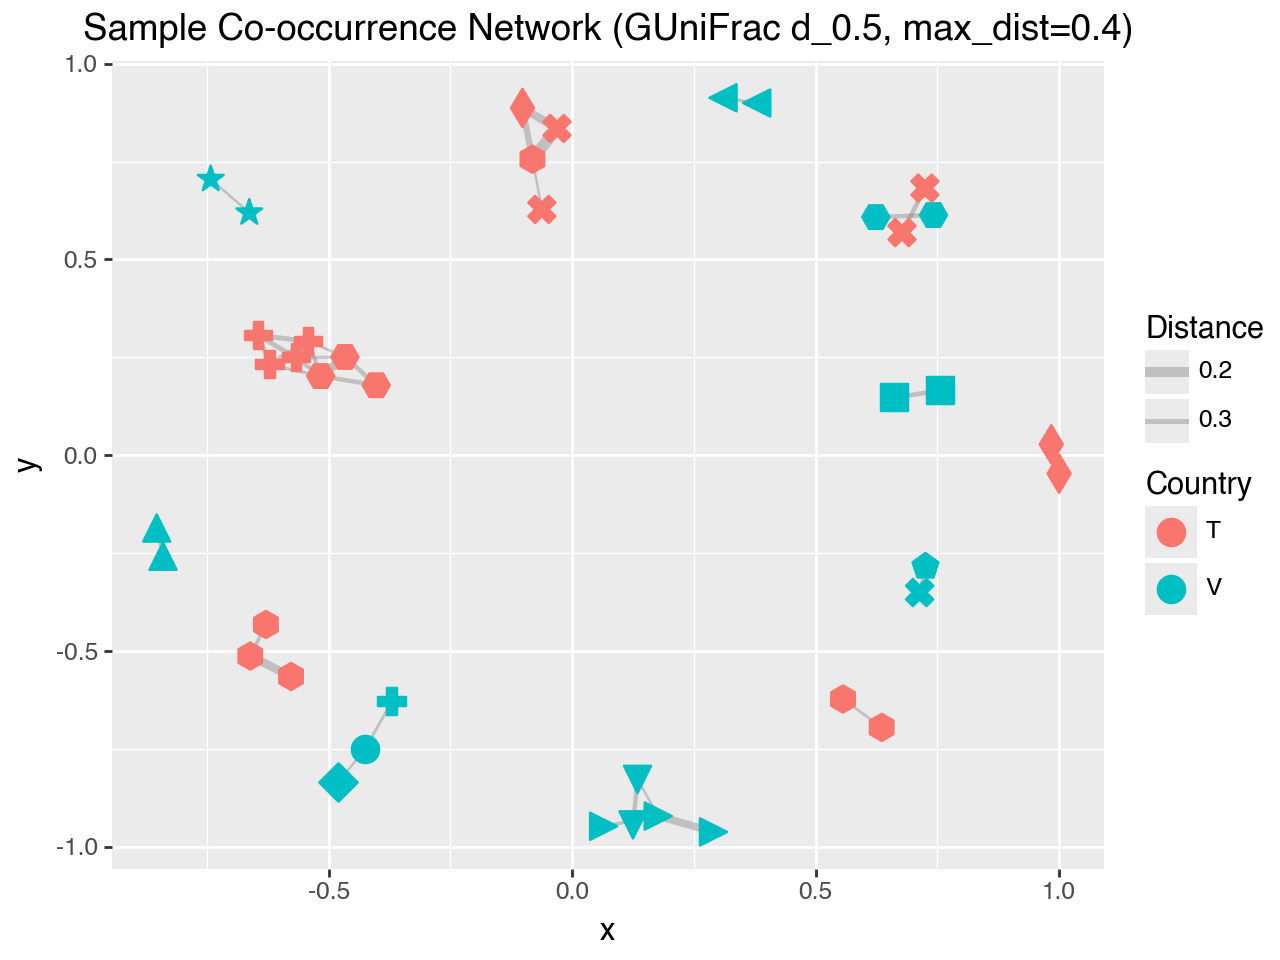

In [40]:
# R: plot_net(physeq_subset, distance=as.dist(d5), maxdist=0.4, color="Country", shape="Latrine")
# keep_isolates=True matches R's default keep.isolates=TRUE
g = make_network(physeq_subset, kind="samples", distance=d5, max_dist=0.4, keep_isolates=False)
p = plot_network(
    g,
    physeq_subset,
    color="Country",
    shape="Latrine",
    title="Sample Co-occurrence Network (GUniFrac d_0.5, max_dist=0.4)",
)
p

---
### 10. DESeq2 Export — `to_deseq2`

`Phyloseq.to_deseq2()` returns a `(counts, metadata)` tuple ready to pass directly to `pydeseq2.DeseqDataSet`. This covers the R tutorial's use of DESeq for dispersion estimation and any downstream differential-abundance work.

`counts` is a samples × taxa DataFrame of raw integer read counts; `metadata` is the sample metadata with a matching index.

In [ ]:
from pydeseq2.dds import DeseqDataSet

# R: cds <- newCountDataSet(t(otu_table(physeq)), conditions=sample_data(physeq)$Country)
counts, metadata = physeq.to_deseq2()

print(f"counts:   {counts.shape}   (samples × taxa)")
print(f"metadata: {metadata.shape}  (samples × variables)")
print()

# Pass directly to pydeseq2 for differential abundance or dispersion analysis:
#   dds = DeseqDataSet(counts=counts, metadata=metadata, design="~Country")
#   dds.deseq2()
dds = DeseqDataSet(counts=counts, metadata=metadata, design="~Country", quiet=True)
print(dds)